In [1]:
"""
Лабораторная работа №4: Q-обучение
"""

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import math
import gymnasium as gym

In [2]:
# Создание виртуального дисплея для отображения изображений (для систем без монитора)
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = '1'

In [8]:
# Часть 1: Класс QLearningAgent


class QLearningAgent:
    """
    Агент, реализующий алгоритм Q-обучения.

    Q-learning - это метод обучения с подкреплением без модели,
    который позволяет агенту учиться оптимальной политике,
    обновляя Q-значения для пар (состояние, действие).
    """

    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        """
        Инициализация агента Q-обучения.

        Параметры:
        -----------
        alpha : float
            Скорость обучения (learning rate). Определяет, насколько сильно
            обновляются Q-значения при каждом шаге.
        epsilon : float
            Параметр исследования (exploration rate). Вероятность выбора
            случайного действия вместо оптимального.
        discount : float
            Коэффициент дисконтирования (gamma). Определяет важность будущих наград.
        get_legal_actions : function
            Функция, возвращающая список допустимых действий для заданного состояния.
        """
        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0.0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        """Возвращает Q(state, action) - текущую оценку ценности пары (состояние, действие)."""
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """Устанавливает Q(state, action) в указанное значение."""
        self._qvalues[state][action] = value

    def get_value(self, state):
        """
        Вычисляет оценку V(s) = max_a Q(s, a) для заданного состояния.
        V(s) представляет собой максимальную ожидаемую суммарную награду из состояния s.
        """
        possible_actions = self.get_legal_actions(state)

        # Если нет допустимых действий, возвращаем 0.0
        if len(possible_actions) == 0:
            return 0.0

        # Находим максимальное Q-значение среди всех допустимых действий
        # Используем get_qvalue для получения значений
        max_qvalue = max(self.get_qvalue(state, action) for action in possible_actions)
        return max_qvalue

    def update(self, state, action, reward, next_state):
        """
        Обновляет Q-значение согласно правилу Q-learning:
        Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * max_a' Q(s', a'))

        Параметры:
        -----------
        state : текущее состояние
        action : выполненное действие
        reward : полученная награда
        next_state : следующее состояние
        """
        gamma = self.discount
        learning_rate = self.alpha

        # Получаем текущее Q-значение
        current_qvalue = self.get_qvalue(state, action)

        # Получаем максимальное Q-значение для следующего состояния
        next_value = self.get_value(next_state)

        # Вычисляем целевое Q-значение по формуле Беллмана
        target_qvalue = reward + gamma * next_value

        # Обновляем Q-значение с использованием скорости обучения
        new_qvalue = (1 - learning_rate) * current_qvalue + learning_rate * target_qvalue

        # Сохраняем обновленное значение
        self.set_qvalue(state, action, new_qvalue)

    def get_best_action(self, state):
        """
        Возвращает наилучшее действие для данного состояния на основе текущих Q-значений.
        Если несколько действий имеют одинаковое максимальное значение, выбирается первое.
        """
        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:
            return None

        # Находим действие с максимальным Q-значением
        # Используем ключ для сравнения по Q-значению
        best_action = max(possible_actions, key=lambda a: self.get_qvalue(state, a))
        return best_action

    def get_action(self, state):
        """
        Выбирает действие с использованием epsilon-жадной политики.
        С вероятностью epsilon выбирается случайное действие (исследование),
        иначе выбирается наилучшее действие (эксплуатация).
        """
        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:
            return None

        # Исследование: выбираем случайное действие с вероятностью epsilon
        if random.random() < self.epsilon:
            return random.choice(possible_actions)

        # Эксплуатация: выбираем наилучшее действие
        return self.get_best_action(state)

In [9]:
# Часть 2: Обучение агента на среде Taxi-v3

def train_taxi_agent():
    """
    Обучение агента Q-learning на среде Taxi-v3.
    В среде Taxi агент должен научиться подбирать и высаживать пассажиров.
    """

    print("Часть 1: Обучение агента на среде Taxi-v3")


    # Создаем среду Taxi-v3
    env = gym.make("Taxi-v3")

    # Получаем количество состояний и действий
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    print(f"Количество состояний: {n_states}")
    print(f"Количество действий: {n_actions}")

    # Функция для получения допустимых действий в состоянии
    def get_legal_actions(state):
        # В Taxi-v3 все действия допустимы во всех состояниях
        return list(range(n_actions))

    # Создаем агента с параметрами
    alpha = 0.1      # Скорость обучения
    epsilon = 0.1    # Вероятность исследования
    discount = 0.99  # Коэффициент дисконтирования

    agent = QLearningAgent(alpha, epsilon, discount, get_legal_actions)

    # Параметры обучения
    n_episodes = 5000
    max_steps_per_episode = 200

    # Для отслеживания прогресса
    episode_rewards = []
    episode_lengths = []

    print("\nНачало обучения...")

    for episode in range(n_episodes):
        state, info = env.reset()
        total_reward = 0
        steps = 0

        for step in range(max_steps_per_episode):
            # Агент выбирает действие
            action = agent.get_action(state)

            # Выполняем действие в среде
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Обновляем Q-значения
            agent.update(state, action, reward, next_state)

            total_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)

        # Уменьшаем epsilon со временем для снижения исследования
        if episode > 0 and episode % 100 == 0:
            agent.epsilon *= 0.99
            agent.epsilon = max(agent.epsilon, 0.01)

        # Выводим прогресс каждые 500 эпизодов
        if (episode + 1) % 500 == 0:
            avg_reward = np.mean(episode_rewards[-500:])
            print(f"Эпизод {episode + 1}/{n_episodes}, Средняя награда: {avg_reward:.2f}, Epsilon: {agent.epsilon:.3f}")

    print("\nОбучение завершено!")

    # Визуализация результатов обучения
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(episode_rewards)
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизод')
    plt.ylabel('Суммарная награда')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    # Сглаживание для лучшей визуализации
    window = 50
    smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(smoothed_rewards)
    plt.title(f'Сглаженная награда (окно={window})')
    plt.xlabel('Эпизод')
    plt.ylabel('Средняя награда')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('taxi_training_results.png', dpi=100)
    plt.show()

    # Тестирование обученного агента
    print("\nТестирование обученного агента...")
    test_episodes = 100
    test_rewards = []

    for episode in range(test_episodes):
        state, info = env.reset()
        total_reward = 0
        steps = 0

        for step in range(max_steps_per_episode):
            # Используем greedy политику (без исследования)
            action = agent.get_best_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        test_rewards.append(total_reward)

    print(f"Средняя награда за {test_episodes} тестовых эпизодов: {np.mean(test_rewards):.2f}")
    print(f"Минимальная награда: {np.min(test_rewards)}")
    print(f"Максимальная награда: {np.max(test_rewards)}")
    print(f"Стандартное отклонение: {np.std(test_rewards):.2f}")

    env.close()
    return agent

In [10]:
# Часть 3: Бинаризованные пространства состояний для CartPole

class Binarizer(gym.ObservationWrapper):
    """
    Обертка для среды, которая бинаризует (дискретизирует) непрерывные наблюдения.

    Преобразует непрерывные значения состояний в дискретные кортежи,
    округляя значения до заданного количества знаков после запятой.
    """

    def __init__(self, env, n_digits=None):
        """
        Инициализация обертки.

        Параметры:
        -----------
        env : среда Gymnasium
        n_digits : list или int
            Количество знаков после запятой для округления.
            Если list, то для каждого измерения используется своё значение.
            Если None, значения подбираются автоматически.
        """
        super().__init__(env)
        self.env = env

        # Если n_digits не задан, подбираем значения на основе анализа среды
        if n_digits is None:
            # Для CartPole эмпирически подобранные значения
            # [позиция, скорость, угол, угловая скорость]
            self.n_digits = [1, 2, 2, 2]
        elif isinstance(n_digits, (int, float)):
            # Если задано одно число, используем его для всех измерений
            self.n_digits = [n_digits] * env.observation_space.shape[0]
        else:
            self.n_digits = n_digits

    def observation(self, observation):
        """
        Преобразует наблюдение в дискретную форму.

        Параметры:
        -----------
        observation : numpy array
            Исходное наблюдение из среды

        Returns:
        --------
        tuple
            Дискретизированное наблюдение
        """
        # Округляем каждое измерение до указанного количества знаков
        discretized = []
        for i, value in enumerate(observation):
            n_digit = self.n_digits[i] if i < len(self.n_digits) else self.n_digits[0]
            discretized.append(round(value, n_digit))

        return tuple(discretized)


def analyze_observations(env, n_samples=1000):
    """
    Анализирует распределение наблюдений в среде.

    Параметры:
    -----------
    env : среда Gymnasium
    n_samples : int
        Количество шагов для анализа
    """

    print("Часть 2: Анализ распределения наблюдений в CartPole")


    seen_observations = []

    for _ in range(n_samples):
        state, info = env.reset()
        seen_observations.append(state)

        done = False
        while not done:
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            seen_observations.append(next_state)

    seen_observations = np.array(seen_observations)

    # Визуализируем распределение для каждого измерения
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    feature_names = ['Позиция тележки', 'Скорость тележки', 'Угол маятника', 'Угловая скорость']

    for i in range(env.observation_space.shape[0]):
        axes[i].hist(seen_observations[:, i], bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{feature_names[i]}')
        axes[i].set_xlabel('Значение')
        axes[i].set_ylabel('Частота')
        axes[i].grid(True, alpha=0.3)

        # Добавляем статистику
        mean_val = np.mean(seen_observations[:, i])
        std_val = np.std(seen_observations[:, i])
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'μ={mean_val:.3f}')
        axes[i].axvline(mean_val + std_val, color='orange', linestyle=':', alpha=0.7)
        axes[i].axvline(mean_val - std_val, color='orange', linestyle=':', alpha=0.7)
        axes[i].legend()

    plt.suptitle('Распределение наблюдений в CartPole (случайная политика)')
    plt.tight_layout()
    plt.savefig('cartpole_observations.png', dpi=100)
    plt.show()

    return seen_observations


def train_cartpole_agent():
    """
    Обучение агента Q-learning на среде CartPole с использованием бинаризации.
    """
    print("Часть 3: Обучение агента на CartPole с бинаризацией")

    # Создаем исходную среду
    env = gym.make("CartPole-v1")

    # Анализируем распределение наблюдений
    analyze_observations(env)

    # Создаем обертку для бинаризации
    env_binarized = Binarizer(env)

    print(f"\nИсходное пространство наблюдений: {env.observation_space}")
    print(f"Бинаризованное пространство наблюдений: (дискретные кортежи из 4 элементов)")

    # Получаем количество действий
    n_actions = env.action_space.n
    print(f"Количество действий: {n_actions}")

    # Функция для получения допустимых действий
    def get_legal_actions(state):
        return list(range(n_actions))

    # Создаем агента
    alpha = 0.1      # Скорость обучения
    epsilon = 0.1    # Начальная вероятность исследования
    discount = 0.99  # Коэффициент дисконтирования

    agent = QLearningAgent(alpha, epsilon, discount, get_legal_actions)

    # Параметры обучения
    n_episodes = 10000
    max_steps_per_episode = 500

    episode_rewards = []
    episode_lengths = []

    print("\nНачало обучения CartPole...")
    print("Примечание: Обучение может занять некоторое время из-за дискретизации пространства состояний.")

    for episode in range(n_episodes):
        # Сбрасываем среду (возвращает state и info в gymnasium)
        state, info = env_binarized.reset()
        total_reward = 0
        steps = 0

        for step in range(max_steps_per_episode):
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, info = env_binarized.step(action)
            done = terminated or truncated

            # В CartPole награда за каждый шаг = 1
            agent.update(state, action, reward, next_state)

            total_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)

        # Динамическое уменьшение epsilon
        if episode > 0 and episode % 100 == 0:
            agent.epsilon *= 0.98
            agent.epsilon = max(agent.epsilon, 0.01)

        # Вывод прогресса
        if (episode + 1) % 1000 == 0:
            avg_reward = np.mean(episode_rewards[-1000:])
            print(f"Эпизод {episode + 1}/{n_episodes}, "
                  f"Средняя награда: {avg_reward:.2f}, "
                  f"Epsilon: {agent.epsilon:.3f}")

    print("\nОбучение CartPole завершено!")

    # Визуализация результатов
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(episode_rewards, alpha=0.5, label='Исходные данные')
    window = 100
    smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    plt.plot(smoothed, 'r-', linewidth=2, label=f'Сглаженные (окно={window})')
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизод')
    plt.ylabel('Суммарная награда')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(episode_lengths, alpha=0.5)
    smoothed_lengths = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
    plt.plot(smoothed_lengths, 'r-', linewidth=2)
    plt.title('Длина эпизода (количество шагов)')
    plt.xlabel('Эпизод')
    plt.ylabel('Шагов до завершения')
    plt.grid(True, alpha=0.3)

    plt.suptitle('Результаты обучения Q-learning на CartPole (бинаризованное состояние)')
    plt.tight_layout()
    plt.savefig('cartpole_training_results.png', dpi=100)
    plt.show()

    # Тестирование
    print("\nТестирование обученного агента на CartPole...")
    test_episodes = 100
    test_rewards = []

    for episode in range(test_episodes):
        state, info = env_binarized.reset()
        total_reward = 0

        for step in range(500):
            action = agent.get_best_action(state)
            next_state, reward, terminated, truncated, info = env_binarized.step(action)
            done = terminated or truncated

            total_reward += reward
            state = next_state

            if done:
                break

        test_rewards.append(total_reward)

    print(f"Средняя награда за {test_episodes} тестовых эпизодов: {np.mean(test_rewards):.2f}")
    print(f"Максимальная награда: {np.max(test_rewards)}")
    print(f"Успешность (награда >= 475): {np.sum(np.array(test_rewards) >= 475) / test_episodes * 100:.1f}%")

    env.close()
    env_binarized.close()

    return agent

ЛАБОРАТОРНАЯ РАБОТА №4: Q-ОБУЧЕНИЕ

Данная лабораторная работа демонстрирует:
1. Реализацию алгоритма Q-обучения
2. Обучение агента на среде Taxi-v3
3. Бинаризацию непрерывных состояний для CartPole-v1
4. Обучение агента на дискретизированных состояниях CartPole

Часть 1: Обучение агента на среде Taxi-v3
Количество состояний: 500
Количество действий: 6

Начало обучения...
Эпизод 500/5000, Средняя награда: -185.46, Epsilon: 0.096
Эпизод 1000/5000, Средняя награда: -29.13, Epsilon: 0.091
Эпизод 1500/5000, Средняя награда: -1.79, Epsilon: 0.087
Эпизод 2000/5000, Средняя награда: 2.31, Epsilon: 0.083
Эпизод 2500/5000, Средняя награда: 3.86, Epsilon: 0.079
Эпизод 3000/5000, Средняя награда: 3.84, Epsilon: 0.075
Эпизод 3500/5000, Средняя награда: 4.15, Epsilon: 0.071
Эпизод 4000/5000, Средняя награда: 3.67, Epsilon: 0.068
Эпизод 4500/5000, Средняя награда: 4.59, Epsilon: 0.064
Эпизод 5000/5000, Средняя награда: 4.37, Epsilon: 0.061

Обучение завершено!


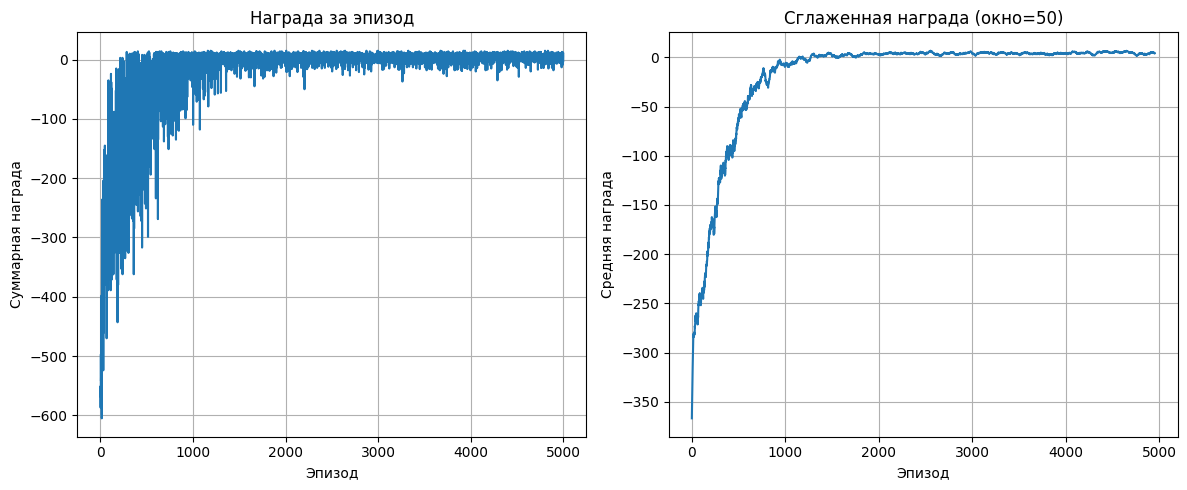


Тестирование обученного агента...
Средняя награда за 100 тестовых эпизодов: 7.94
Минимальная награда: 4
Максимальная награда: 14
Стандартное отклонение: 2.74
Часть 3: Обучение агента на CartPole с бинаризацией
Часть 2: Анализ распределения наблюдений в CartPole


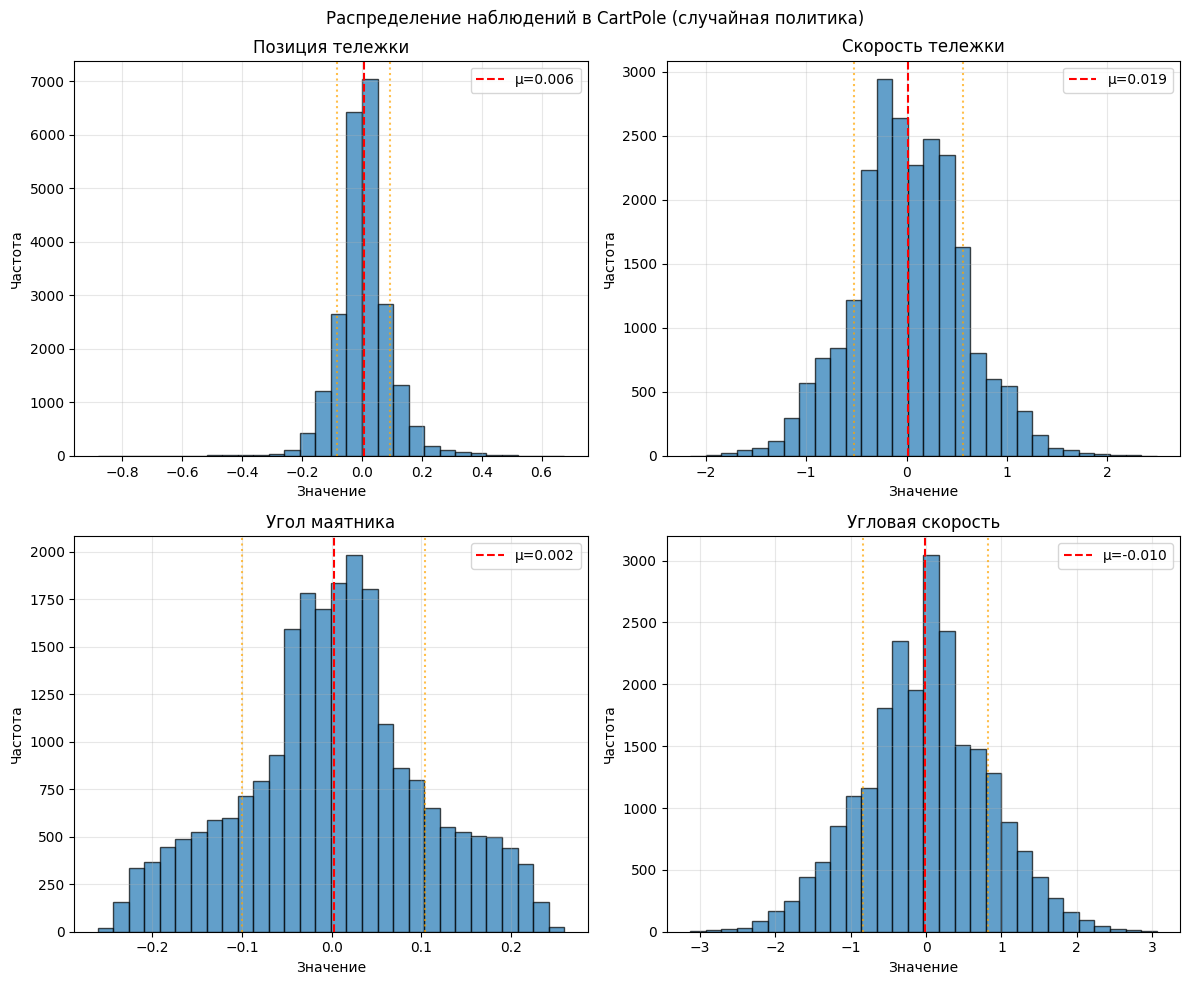


Исходное пространство наблюдений: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Бинаризованное пространство наблюдений: (дискретные кортежи из 4 элементов)
Количество действий: 2

Начало обучения CartPole...
Примечание: Обучение может занять некоторое время из-за дискретизации пространства состояний.
Эпизод 1000/10000, Средняя награда: 9.95, Epsilon: 0.083
Эпизод 2000/10000, Средняя награда: 10.00, Epsilon: 0.068
Эпизод 3000/10000, Средняя награда: 10.03, Epsilon: 0.056
Эпизод 4000/10000, Средняя награда: 10.09, Epsilon: 0.045
Эпизод 5000/10000, Средняя награда: 10.01, Epsilon: 0.037
Эпизод 6000/10000, Средняя награда: 9.99, Epsilon: 0.030
Эпизод 7000/10000, Средняя награда: 9.92, Epsilon: 0.025
Эпизод 8000/10000, Средняя награда: 9.90, Epsilon: 0.020
Эпизод 9000/10000, Средняя награда: 9.90, Epsilon: 0.017
Эпизод 10000/10000, Средняя награда: 9.86, Epsilon: 0.014

Обучение CartPole завершено!


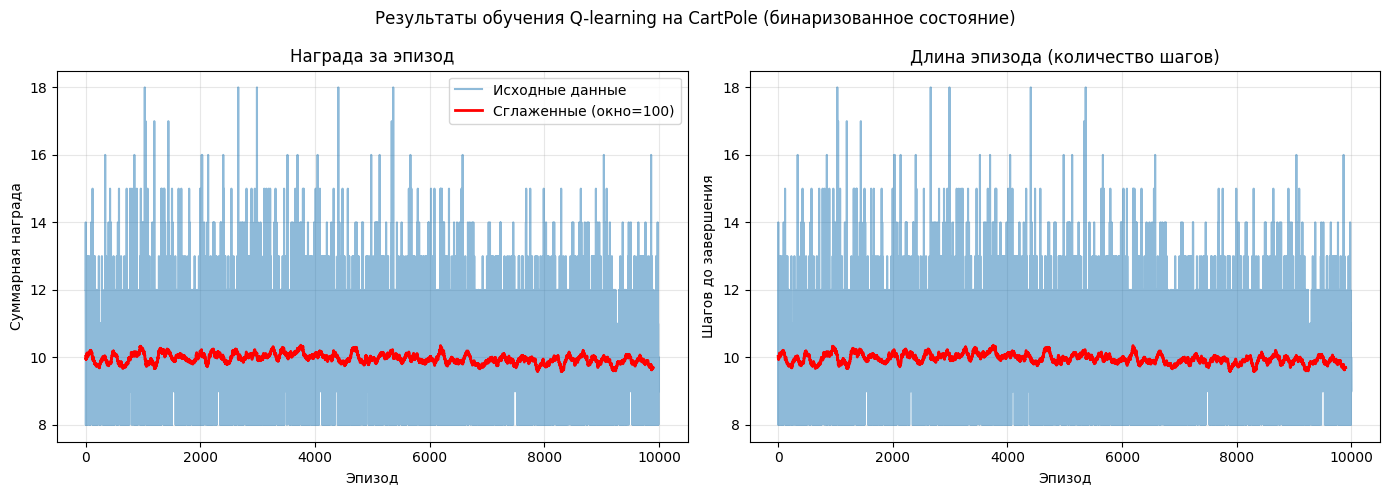


Тестирование обученного агента на CartPole...
Средняя награда за 100 тестовых эпизодов: 9.99
Максимальная награда: 14.0
Успешность (награда >= 475): 0.0%


In [11]:
# Основной блок выполнения

if __name__ == "__main__":
    print("ЛАБОРАТОРНАЯ РАБОТА №4: Q-ОБУЧЕНИЕ")
    print("\nДанная лабораторная работа демонстрирует:")
    print("1. Реализацию алгоритма Q-обучения")
    print("2. Обучение агента на среде Taxi-v3")
    print("3. Бинаризацию непрерывных состояний для CartPole-v1")
    print("4. Обучение агента на дискретизированных состояниях CartPole")
    print()

    # Часть 1: Обучение на Taxi-v3
    taxi_agent = train_taxi_agent()

    # Часть 2: Обучение на CartPole с бинаризацией
    cartpole_agent = train_cartpole_agent()